# Exploratory Data Analysis: Social Media Sentiment
**Task:** EDA, Basic Statistics, and Data Summary.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from wordcloud import STOPWORDS
from collections import Counter
import re

# Set plot style
sns.set_theme(style="whitegrid")

Loading Data & Summary

In [40]:
# Load the dataset (adjust path if needed)
df = pd.read_csv(r'C:\Users\User\Documents\pwr\magisterkie\ML\data\synthetic_social_media_data.csv')

# Display basic information about the dataset
print("Dataset Summary:")
print(df.info())

# Display the first few rows
print("\nFirst 5 rows:")
display(df.head())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Post ID              2000 non-null   object
 1   Post Content         2000 non-null   object
 2   Sentiment Label      2000 non-null   object
 3   Number of Likes      2000 non-null   int64 
 4   Number of Shares     2000 non-null   int64 
 5   Number of Comments   2000 non-null   int64 
 6   User Follower Count  2000 non-null   int64 
 7   Post Date and Time   2000 non-null   object
 8   Post Type            2000 non-null   object
 9   Language             2000 non-null   object
dtypes: int64(4), object(6)
memory usage: 156.4+ KB
None

First 5 rows:


,Post ID,Post Content,Sentiment Label,Number of Likes,Number of Shares,Number of Comments,User Follower Count,Post Date and Time,Post Type,Language
0,aa391375-7355-44b7-bcbf-97fb4e5a2ba3,Word who nor center everything better politica...,Neutral,157,243,64,4921,2024-01-10 00:14:21,video,fr
1,1c9ec98d-437a-48d9-9cba-bd5ad853c59a,Begin administration population good president...,Positive,166,49,121,612,2024-02-03 00:20:11,image,es
2,170e5b5b-1d9a-4d02-a957-93c4dbb18908,Thousand total sign. Agree product relationshi...,Positive,185,224,179,9441,2024-07-25 14:20:23,video,de
3,aec53496-60ee-4a06-8821-093a04dc8770,Individual from news third. Oil forget them di...,Neutral,851,369,39,6251,2024-02-20 09:15:09,text,de
4,4eacddb7-990d-4056-8784-7e1d5c4d1404,Time adult letter see reduce. Attention sudden...,Negative,709,356,52,1285,2024-03-01 04:17:35,image,de



Missing values:
Post ID                0
Post Content           0
Sentiment Label        0
Number of Likes        0
Number of Shares       0
Number of Comments     0
User Follower Count    0
Post Date and Time     0
Post Type              0
Language               0
dtype: int64


The dataset is highly consistent with 2,000 entries and no missing values across all columns, providing a solid foundation for further sentiment modeling.

Basic Statistics

Engagement Statistics:


,Number of Likes,Number of Shares,Number of Comments
count,2000.000000,2000.00000,2000.000000
mean,503.379000,248.48500,102.805000
std,283.210866,145.09499,58.032886
min,1.000000,0.00000,0.000000
25%,267.000000,121.00000,52.000000
50%,505.000000,248.50000,104.500000
75%,740.000000,375.00000,153.250000
max,1000.000000,500.00000,200.000000



Sentiment Label Distribution:
Sentiment Label
Neutral     682
Negative    675
Positive    643
Name: count, dtype: int64


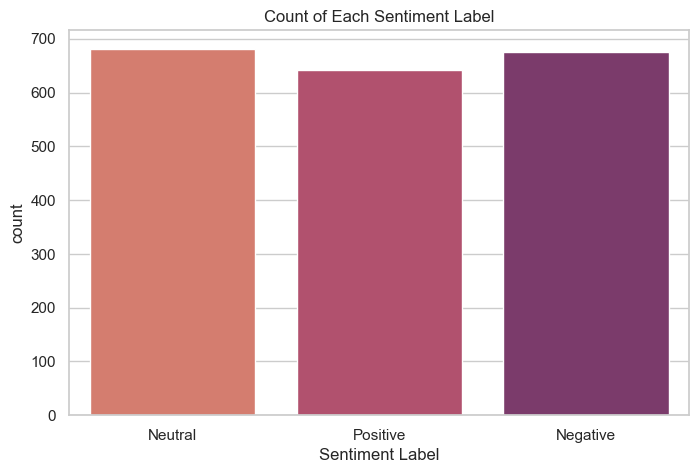

In [41]:
# Statistical summary of numerical engagement metrics
print("Engagement Statistics:")
display(df[['Number of Likes', 'Number of Shares', 'Number of Comments']].describe())

# Check distribution of Sentiment Labels
print("\nSentiment Label Distribution:")
print(df['Sentiment Label'].value_counts())

# Simple plot for Sentiment Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sentiment Label', hue='Sentiment Label', palette='flare', legend=False)
plt.title('Count of Each Sentiment Label')
plt.show()

Engagement Metrics: The data for Likes, Shares, and Comments shows a symmetric spread across the entire range. The mean and median (50th percentile) are nearly identical, indicating a balanced dataset without significant skewness.

Class Balance: The dataset consists of 2,000 records divided almost equally into three categories: Neutral (682), Negative (675), and Positive (643). This ensures that each sentiment class is represented with similar frequency for the modeling phase.

EDA: Review Lengths


Content Length Summary:
                 count        mean        std    min    25%    50%    75%  \
Sentiment Label                                                             
Negative         675.0  227.063704  35.261765  109.0  202.0  231.0  257.0   
Neutral          682.0  224.841642  35.118363  101.0  201.0  228.5  254.0   
Positive         643.0  225.676516  35.881527  112.0  203.0  228.0  256.0   

                   max  
Sentiment Label         
Negative         279.0  
Neutral          279.0  
Positive         279.0  


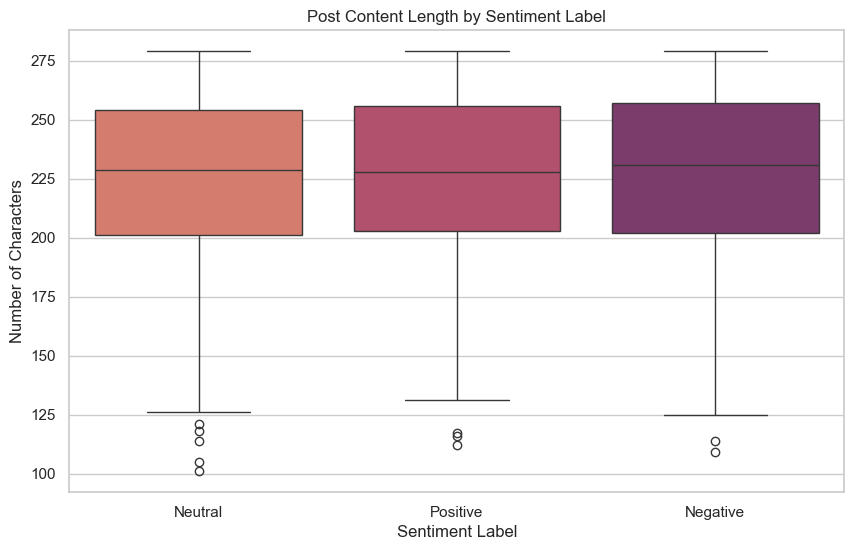

In [43]:
# Calculate length of the post content
df['content_length'] = df['Post Content'].apply(len)

# Descriptive statistics for length
print("\nContent Length Summary:")
print(df.groupby('Sentiment Label')['content_length'].describe())

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Sentiment Label', y='content_length', hue='Sentiment Label', palette='flare', legend=False)
plt.title('Post Content Length by Sentiment Label')
plt.ylabel('Number of Characters')
plt.show()

The post lengths are nearly identical across all categories, with average values around 226 characters and a matching maximum length of 279 characters for each sentiment.

EDA: Word Clouds for Sentiment

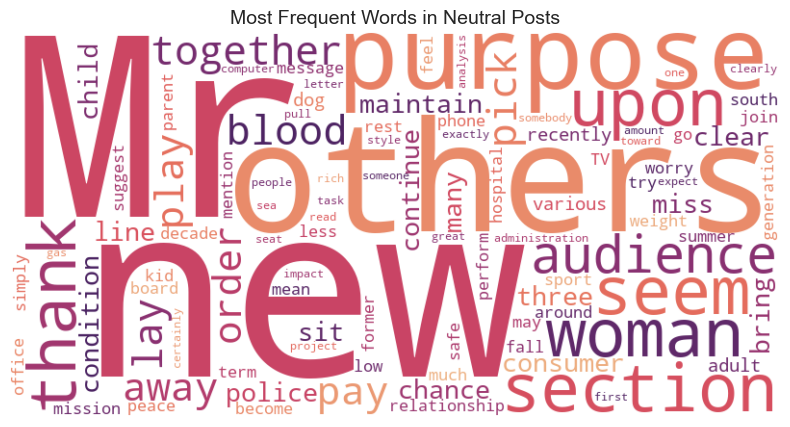

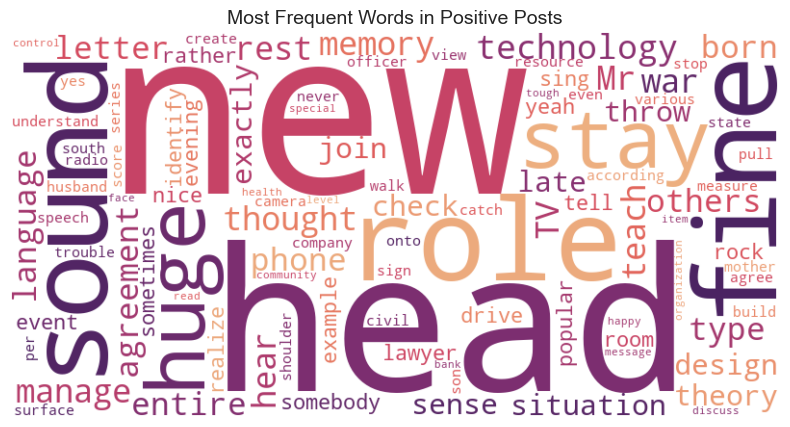

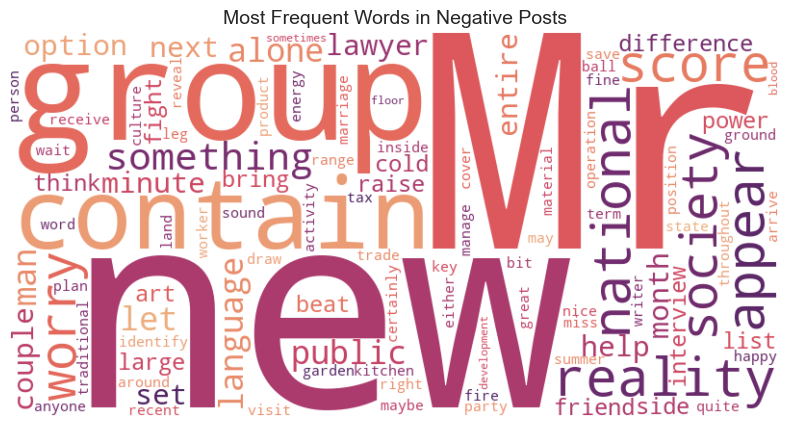

In [50]:
def generate_flare_wordcloud(sentiment):
    # Filter text
    text = " ".join(content for content in df[df['Sentiment Label'] == sentiment]['Post Content'])
    
    # Create word cloud with flare colormap
    wc = WordCloud(
        stopwords=STOPWORDS,
        background_color="white", 
        max_words=100, 
        colormap='flare',  # This matches your preferred style
        width=800, 
        height=400
    ).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Most Frequent Words in {sentiment} Posts", fontsize=14)
    plt.show()

# Run for each sentiment
for label in df['Sentiment Label'].unique():
    generate_flare_wordcloud(label)

TOP WORDS FOR: Positive


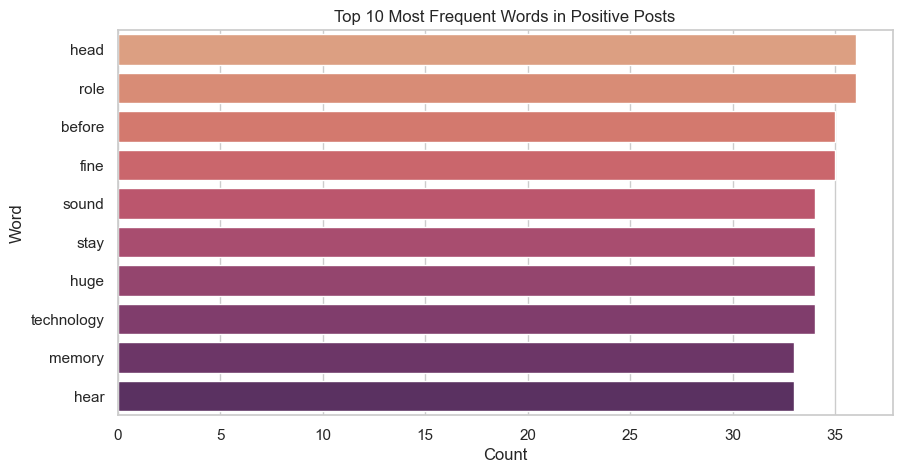

,Word,Count
0,head,36
1,role,36
2,before,35
3,fine,35
4,sound,34
5,stay,34
6,huge,34
7,technology,34
8,memory,33
9,hear,33


TOP WORDS FOR: Neutral


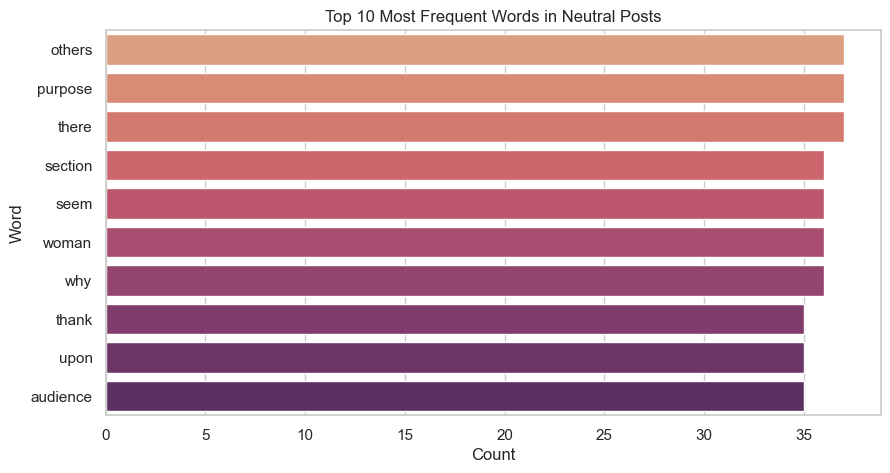

,Word,Count
0,others,37
1,purpose,37
2,there,37
3,section,36
4,seem,36
5,woman,36
6,why,36
7,thank,35
8,upon,35
9,audience,35


TOP WORDS FOR: Negative


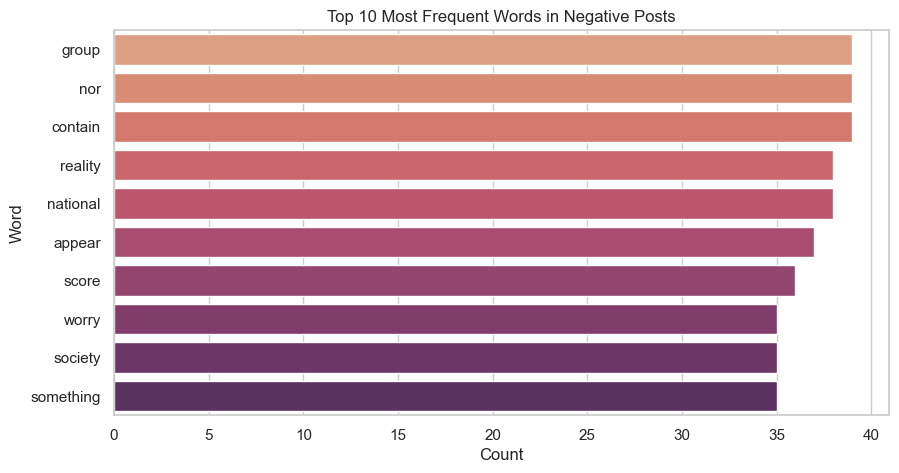

,Word,Count
0,group,39
1,nor,39
2,contain,39
3,reality,38
4,national,38
5,appear,37
6,score,36
7,worry,35
8,society,35
9,something,35


In [45]:
def get_top_words_stats(sentiment, top_n=10):
    # 1. Combine all text for given sentiment
    text = " ".join(content for content in df[df['Sentiment Label'] == sentiment]['Post Content'].dropna())
    
    # 2. Clean text a bit (lowercase and only words)
    words = re.findall(r'\w+', text.lower())
    
    # 3. Filter out common boring words (stopwords)
    # You can add more to this list
    stopwords = set(['the', 'and', 'to', 'of', 'a', 'in', 'is', 'it', 'for', 'on', 'with', 'that', 'this'])
    filtered_words = [w for w in words if w not in stopwords and len(w) > 2]
    
    # 4. Count and create a DataFrame
    word_counts = Counter(filtered_words).most_common(top_n)
    word_df = pd.DataFrame(word_counts, columns=['Word', 'Count'])
    
    # 5. Plot
    plt.figure(figsize=(10, 5))
    sns.barplot(data=word_df, x='Count', y='Word', hue='Word', palette='flare', legend=False)
    plt.title(f'Top {top_n} Most Frequent Words in {sentiment} Posts')
    plt.show()
    
    return word_df

# Function to get word stats for all sentiments
sentiments = ['Positive', 'Neutral', 'Negative']

for sentiment in sentiments:
    print(f"TOP WORDS FOR: {sentiment}")
    
    # Run the stats function we created earlier
    stats_df = get_top_words_stats(sentiment)
    display(stats_df)

The most frequent words in each category appear with similar regularity, ranging from 33 to 39 occurrences, with 'head' leading in Positive, 'others' in Neutral, and 'group' in Negative posts.

In-Depth Statistical Analysis

In [47]:
# Count posts per language
lang_counts = df['Language'].value_counts()
lang_pct = df['Language'].value_counts(normalize=True) * 100

lang_summary = pd.DataFrame({'Count': lang_counts, 'Percentage (%)': lang_pct})
print("Language Distribution:")
display(lang_summary)

Language Distribution:


,Count,Percentage (%)
Language,,
es,431,21.55
de,424,21.20
en,421,21.05
fr,370,18.50
zh,354,17.70


The dataset contains five languages with comparable frequencies, where Spanish, German, and English each represent approximately 21% of the posts, followed by French (18.5%) and Chinese (17.7%).

In [48]:
# Cross-tabulation of Post Type and Sentiment
post_type_sentiment = pd.crosstab(df['Post Type'], df['Sentiment Label'], normalize='index') * 100
print("Post Type vs Sentiment (in %):")
display(post_type_sentiment.round(2))

Post Type vs Sentiment (in %):


Sentiment Label,Negative,Neutral,Positive
Post Type,,,
image,35.82,34.36,29.82
text,33.54,33.23,33.23
video,31.83,34.68,33.48


The distribution of sentiment remains relatively consistent across all post types, with each format (image, text, video) showing a near-equal split of approximately one-third for each sentiment label.